In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn

Libreria de python pensada para la visualizacion de datos estadisticos.Esta construida sobre Matploty y se integra de forma nativa con pandas.Tiene graficas mas complejas y visuales que su hermana pequeña matploty.

Se usa mucho en los analisis explotarios de datos (EDA), en proyectos de ciencia de datos .

## 1. Grafico de Lineas Categorizado (sns.lineplot)

**Casos uso**: Comparar la evolucion de una variables a lo largo del tiempo , pero separada por categorias.
**Data model** : Tabla(DataFrame) con columnas: tiempo, valor numerico y categoria para poder hacer una agrupacion.

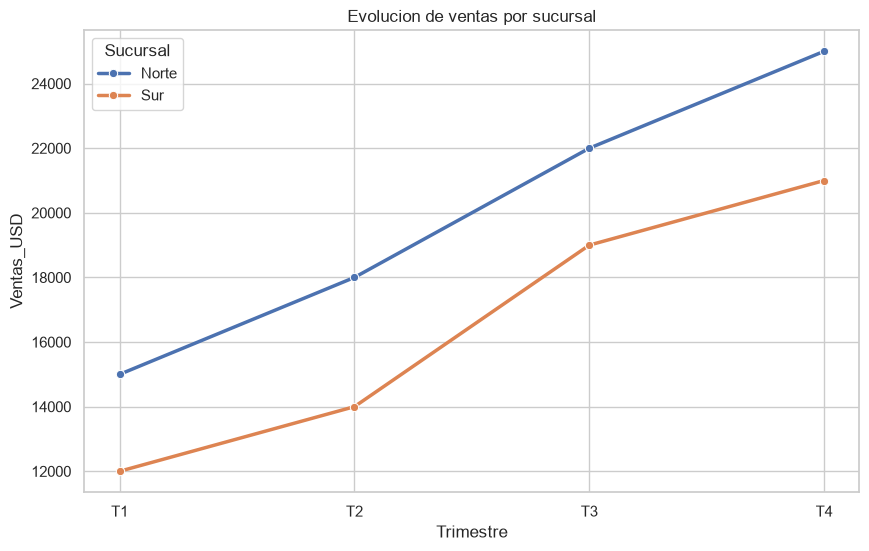

In [2]:
datos = {
    "Trimestre": ["T1", "T2", "T3", "T4", "T1", "T2", "T3", "T4"],
    "Ventas_USD": [15000, 18000, 22000, 25000, 12000, 14000, 19000, 21000],
    "Sucursal": ["Norte", "Norte", "Norte", "Norte", "Sur", "Sur", "Sur", "Sur"]
}

df = pd.DataFrame(datos)

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
plt.title('Evolucion de ventas por sucursal')

sns.lineplot(data=df, x='Trimestre', y='Ventas_USD', hue='Sucursal', marker='o', linewidth= 2.5)

plt.show()



## 2. Grafico de barras agrupado (sns.barplot)

**Casos de uso**: Compara valores promedio ( valores agregados) de diferentes categorias divididas en subgrupos.

**Data Model**: Eje X categorias primarias las que queremos evaluar. eje y valores que queremos comparar numericos, (hue subcategorias)

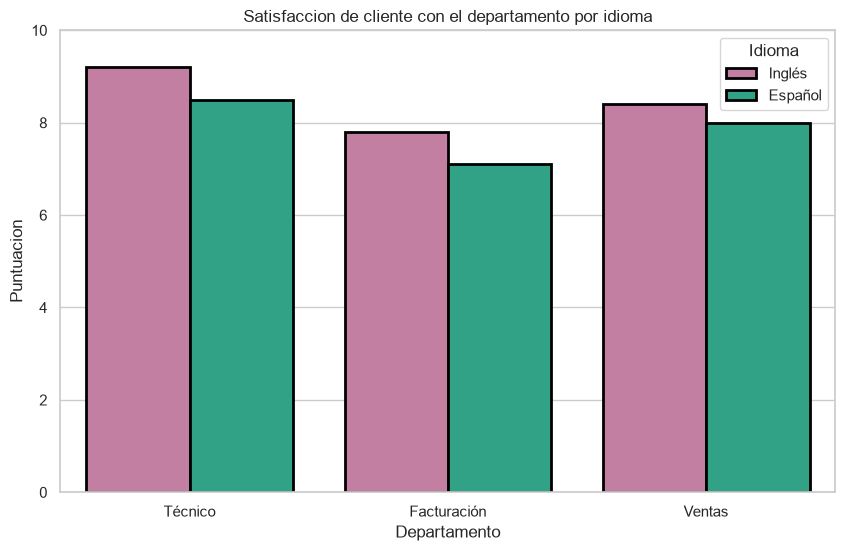

In [3]:
datos_soporte = {
    "Departamento": ["Técnico", "Técnico", "Facturación", "Facturación", "Ventas", "Ventas"],
    "Puntuacion": [8.5, 9.2, 7.1, 7.8, 8.0, 8.4],
    "Idioma": ["Español", "Inglés", "Español", "Inglés", "Español", "Inglés"]
}

df_soporte = pd.DataFrame(datos_soporte)

plt.figure(figsize=(10,6))

plt.title('Satisfaccion de cliente con el departamento por idioma')
# este grafico tiene la posibilidad de ponerle una escala
plt.ylim(0,10)#escala de 1:10

sns.barplot(data=df_soporte, x='Departamento', y='Puntuacion', hue='Idioma', edgecolor='black', linewidth=2, alpha=1, hue_order=['Inglés', 'Español'], dodge=True, palette=["#CF73A1","#1fb58f"])

plt.show()

## 3.Grafico de dispersion relacional ( sns.Scatterplot)

**Casos de uso**: visulaizar relaciones entre dos variables cuantitativas y agregar dimensiones adicionales.
**DataModel** : Coordenadas X e Y numericas. 


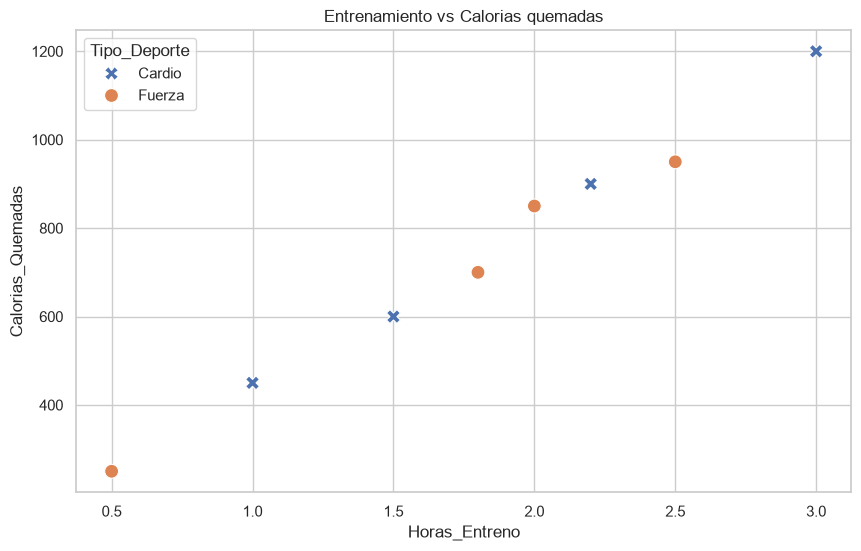

In [4]:
datos_deporte = {
    "Horas_Entreno": [1.5, 2.0, 1.0, 3.0, 2.5, 0.5, 2.2, 1.8],
    "Calorias_Quemadas": [600, 850, 450, 1200, 950, 250, 900, 700],
    "Tipo_Deporte": ["Cardio", "Fuerza", "Cardio", "Cardio", "Fuerza", "Fuerza", "Cardio", "Fuerza"]
}

df_deporte = pd.DataFrame(datos_deporte)

plt.figure(figsize=(10,6))
plt.title('Entrenamiento vs Calorias quemadas')

sns.scatterplot(data=df_deporte, x='Horas_Entreno', y='Calorias_Quemadas', hue='Tipo_Deporte', s=100, style='Tipo_Deporte', markers=['X', 'o'])

plt.show()


## 4. Histograma con Densidad(sns.histplot)

**Casos de uso**: Mostrar distribucion de datos con una curva que suavice dicha distribucion (KDE) que facilita ver los picos y la concentracion. ( Todos lo que quede por debajo de la curva)
**DataModel**: un unico listado numerico, ya que medimos repeticion y concentracion.

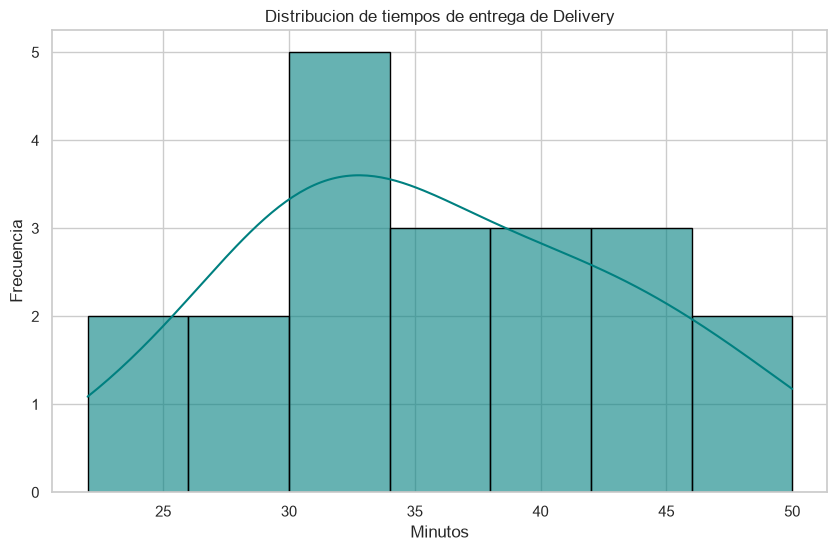

In [5]:
# Dataset: Tiempos de entrega de comida a domicilio (en minutos)
tiempos = [22, 25, 28, 30, 31, 32, 33, 35, 38, 40, 41, 42, 45, 48, 50, 29, 31, 35, 36, 44]

df_tiempos = pd.DataFrame({'Tiempo_minutos': tiempos})

plt.figure(figsize=(10,6))
plt.title('Distribucion de tiempos de entrega de Delivery')

sns.histplot(data=df_tiempos, x='Tiempo_minutos', color='teal', alpha=0.6,bins=7,edgecolor='black', kde=True)

plt.xlabel('Minutos')
plt.ylabel('Frecuencia')

plt.show()

### 5. Diagrama de caja (sns.boxplot)

**Casos de uso**: Visualizaciones distribuciones estadisticas (mediana,outliers,rango intercuartil) comparando multiples grupos.
**DataModel**: Columna en eje X que sea la categorizacion, Columna numerica en el eje de Y.

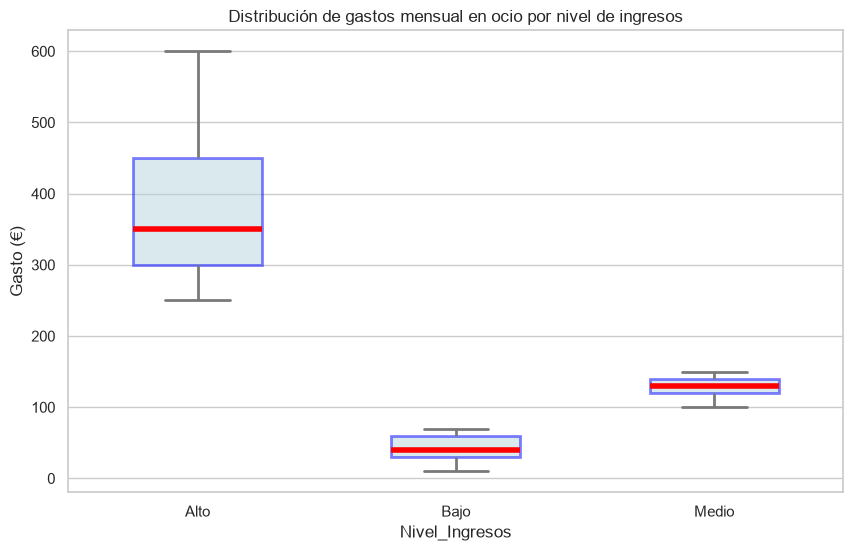

In [7]:
# Dataset: Gasto mensual en ocio agrupado por nivel de ingresos del usuario
datos_ocio = {
    "Nivel_Ingresos": ["Bajo"]*5 + ["Medio"]*5 + ["Alto"]*5,
    "Gasto_Ocio": [
        10, 60, 40, 70, 30,          # Ingreso Bajo
        120, 150, 100, 130, 140,     # Ingreso Medio
        300, 450, 250, 350, 600      # Ingreso Alto (600 es un valor atípico alto)
    ]
}
df_ocio = pd.DataFrame(datos_ocio)

plt.figure(figsize=(10,6))
plt.title('Distribución de gastos mensual en ocio por nivel de ingresos')
plt.ylabel('Gasto (€)')
sns.boxplot(data=df_ocio, x="Nivel_Ingresos", y="Gasto_Ocio", order=["Alto", "Bajo", "Medio"], width=0.5, linewidth=2, medianprops={"color": 'red', "linewidth":4}, color="lightblue", boxprops={"alpha": 0.5, 'edgecolor': 'blue'})
plt.show()

## 6. Diagrama de Violín (sns.violinplot)

**Casos de uso**: Similiar al boxplot pero muestra la densidad de probabilidad para ver de forma clara si la distribucción es bimodal (dos picos)

**Data Model**: Eje X categoría (cualitativo), Eje Y un valor numerico.


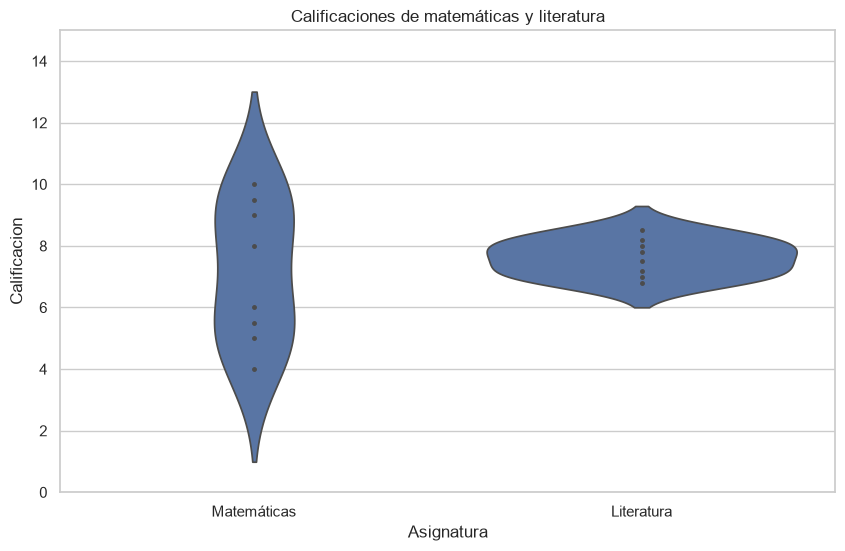

In [8]:
datos_clase = {
    "Asignatura": ["Matemáticas"]*8 + ["Literatura"]*8,
    "Calificacion": [
        4, 5, 5.5, 6, 8, 9, 9.5, 10,       # Matemáticas (distribución dispersa)
        7, 7.5, 7.2, 8, 8.2, 7.8, 6.8, 8.5  # Literatura (muy concentrada alrededor de 7.5-8)
    ]
}

df_clase = pd.DataFrame(datos_clase)

plt.figure(figsize=(10,6))
plt.title('Calificaciones de matemáticas y literatura')
plt.ylim(0,15)
sns.violinplot(data=df_clase, x="Asignatura", y="Calificacion", inner='point')
# inner 'box' (caja por defecto), 'quartile' (líneas de cuartiles), 'point' (puntos exactos), 'stick' (palitos)
plt.show()

## 7. Mapa de calor (sns.heatmap)

**Casos de uso**: Visualizar matrices numericas (multidata) asignado variaciones de color segun la intensidad de valor

**Data Model**: Matriz cuadrada (3x3)

 Matriz de correlacción lineal: Es una tabla que cruza todas las columnas numéricas para medir como se relacionan entre sí Matematicamente.

# Coefiente de Pearson (r) para cada par de variables. Este valor siempre va entre -1 y 1
    # Cerca del 1 (correlaccion positiva): Si una variable sube la otra tambien (Altura y peso)

    # Cerca de -1 (correlacción negativa): Si una variables suba la otra baja (Velocidad y duración de viaje)
    
    # Cerca de 0 (sin correlación): No hay ninguna relacion entre esas dos variables. Los puntos parecen nube desordenada



                 Horas_Sueno  Minutos_Deporte  Cafes_Dia
Horas_Sueno         1.000000        -0.545239  -1.000000
Minutos_Deporte    -0.545239         1.000000   0.545239
Cafes_Dia          -1.000000         0.545239   1.000000


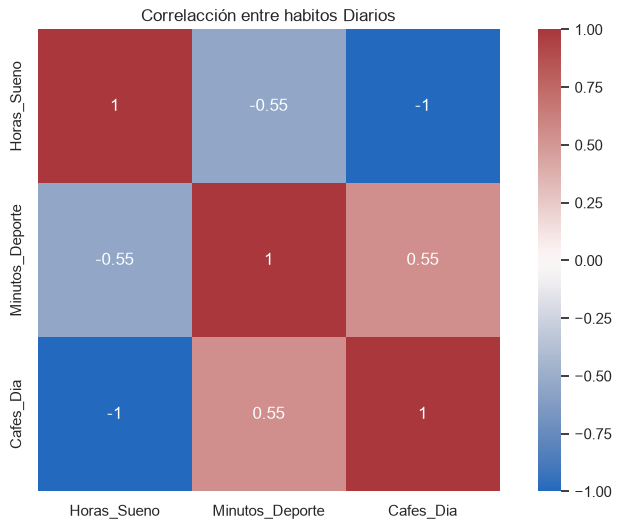

In [ ]:
habits = {
    "Horas_Sueno": [8, 7, 6, 8, 5, 7, 6, 9, 5, 8],
    "Minutos_Deporte": [45, 30, 60, 0, 15, 45, 20, 10, 90, 0],
    "Cafes_Dia": [1, 2, 3, 1, 4, 2, 3, 0, 4, 1]
}
df_habitos = pd.DataFrame(habits)

matriz_correlaccion = df_habitos.corr()
print(matriz_correlaccion)

plt.figure(figsize=(10,6))
plt.title('Correlacción entre habitos Diarios')
sns.heatmap(data=matriz_correlaccion, cmap="vlag", annot=True, square=True)
#. cmap Spectral, vlag, coolwarm 
plt.show()

